<a href="https://colab.research.google.com/github/asheta66/Applications/blob/main/ViT_from_scratch_Alzheimer_MRI_4Class_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer from Scratch for Four-Class Alzheimer MRI Classification

This research notebook adapts the original ViT-from-scratch workflow to the **Alzheimer-MRI-dataset** stored in Google Drive. It classifies axial MRI scans into four disease stages: **No Impairment, Very Mild Impairment, Mild Impairment, and Moderate Impairment**.

The workflow preserves the dataset's official `train` and `test` separation. A stratified validation subset is created **only from the training set**, preventing test-set leakage. Training-only augmentation is intentionally conservative for MRI. The final evaluation reports accuracy, balanced accuracy, Matthews correlation coefficient (MCC), macro precision/recall/F1, per-class performance, confusion matrix, and multiclass one-vs-rest ROC-AUC.

> **Research note:** Run all cells in Google Colab with GPU acceleration. Exact numerical results are produced after training on the Google Drive dataset; they are not fabricated in this notebook.

## 1. Libraries, reproducibility, and experiment setup

This section imports TensorFlow/Keras, scientific Python utilities, and scikit-learn evaluation functions. Fixed random seeds make dataset splitting and initialization more reproducible across runs.

In [1]:
import os, random, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.layers as L

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef,
    precision_recall_fscore_support, accuracy_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
SEED = 42
RANDOM_STATE = 42

def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything()
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Google Drive and discover the Alzheimer MRI dataset

The expected dataset location is `MyDrive/Alzheimer-MRI-dataset`, containing `train` and `test` folders. The code discovers the four class directories instead of assuming a single naming convention, then maps common directory-name variants (for example, `NonDemented` or `VeryMildDemented`) to the research labels used in this notebook.

In [2]:
from google.colab import drive
MOUNT_POINT = "/content/drive"
drive.mount(MOUNT_POINT)

IMAGE_SIZE = 224
BATCH_SIZE = 16
N_CLASSES = 4
VALIDATION_FRACTION = 0.15

DRIVE_DATA_DIR = Path(f"{MOUNT_POINT}/MyDrive/Alzheimer-MRI-dataset")
TRAIN_DIR = DRIVE_DATA_DIR / "train"
TEST_DIR = DRIVE_DATA_DIR / "test"
OUTPUT_DIR = Path(f"{MOUNT_POINT}/MyDrive/Alzheimer_MRI_ViT_4Class_Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
CANONICAL_CLASSES = ["No Impairment", "Very Mild Impairment", "Mild Impairment", "Moderate Impairment"]

def normalize_name(name):
    return ''.join(ch.lower() for ch in name if ch.isalnum())

CLASS_ALIASES = {
    "No Impairment": {"noimpairment", "nonimpaired", "nondemented", "normal", "noimpairmentdemented"},
    "Very Mild Impairment": {"verymildimpairment", "verymilddemented", "verymilddementia"},
    "Mild Impairment": {"mildimpairment", "milddemented", "milddementia"},
    "Moderate Impairment": {"moderateimpairment", "moderatedemented", "moderatedementia"},
}

def class_label_from_folder(folder_name):
    key = normalize_name(folder_name)
    for canonical, aliases in CLASS_ALIASES.items():
        if key in aliases:
            return canonical
    return folder_name.replace('_', ' ').replace('-', ' ').strip()

def scan_split(split_dir, split_name):
    if not split_dir.exists():
        raise FileNotFoundError(f"Required {split_name} directory not found: {split_dir}")
    rows = []
    class_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    if not class_dirs:
        raise ValueError(f"No class folders found under {split_dir}")
    print(f"\n{split_name.upper()} folders:")
    for folder in class_dirs:
        label_name = class_label_from_folder(folder.name)
        files = sorted(p for p in folder.rglob('*') if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS)
        print(f"  {folder.name} -> {label_name}: {len(files):,} images")
        rows.extend({"image_path": str(p), "class_name": label_name, "source_folder": folder.name} for p in files)
    return pd.DataFrame(rows)

df_train_full = scan_split(TRAIN_DIR, "train")
df_test = scan_split(TEST_DIR, "test")

found_classes = set(df_train_full.class_name.unique()) | set(df_test.class_name.unique())
if found_classes != set(CANONICAL_CLASSES):
    raise ValueError(
        "Expected exactly these four mapped classes: " + str(CANONICAL_CLASSES) +
        "\nFound: " + str(sorted(found_classes)) +
        "\nIf your folder names differ, add their normalized names to CLASS_ALIASES."
    )

CLASS_NAMES = CANONICAL_CLASSES
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
for frame in (df_train_full, df_test):
    frame["label"] = frame["class_name"].map(CLASS_TO_ID).astype(int)

print("\nTraining images:", len(df_train_full))
print("Testing images :", len(df_test))
print("\nTraining distribution:\n", df_train_full.class_name.value_counts().reindex(CLASS_NAMES))
print("\nTest distribution:\n", df_test.class_name.value_counts().reindex(CLASS_NAMES))

Mounted at /content/drive

TRAIN folders:
  MildDemented -> Mild Impairment: 717 images
  ModerateDemented -> Moderate Impairment: 52 images
  NonDemented -> No Impairment: 2,560 images
  VeryMildDemented -> Very Mild Impairment: 1,792 images

TEST folders:
  MildDemented -> Mild Impairment: 179 images
  ModerateDemented -> Moderate Impairment: 12 images
  NonDemented -> No Impairment: 640 images
  VeryMildDemented -> Very Mild Impairment: 448 images

Training images: 5121
Testing images : 1279

Training distribution:
 class_name
No Impairment           2560
Very Mild Impairment    1792
Mild Impairment          717
Moderate Impairment       52
Name: count, dtype: int64

Test distribution:
 class_name
No Impairment           640
Very Mild Impairment    448
Mild Impairment         179
Moderate Impairment      12
Name: count, dtype: int64


## 3. Create a validation set without touching the official test set

The official test images remain completely held out. A stratified 15% validation subset is sampled from the supplied training data, so each disease stage remains represented while model selection is isolated from final testing.

In [3]:
df_train, df_valid = train_test_split(
    df_train_full,
    test_size=VALIDATION_FRACTION,
    stratify=df_train_full["class_name"],
    random_state=RANDOM_STATE,
)
df_train = df_train.reset_index(drop=True)
df_valid = df_valid.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

for name, frame in [("Train", df_train), ("Validation", df_valid), ("Test", df_test)]:
    print(f"\n{name}: {len(frame):,} images")
    print(frame["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0))


Train: 4,352 images
class_name
No Impairment           2176
Very Mild Impairment    1523
Mild Impairment          609
Moderate Impairment       44
Name: count, dtype: int64

Validation: 769 images
class_name
No Impairment           384
Very Mild Impairment    269
Mild Impairment         108
Moderate Impairment       8
Name: count, dtype: int64

Test: 1,279 images
class_name
No Impairment           640
Very Mild Impairment    448
Mild Impairment         179
Moderate Impairment      12
Name: count, dtype: int64


## 4. Training-only MRI augmentation and data generators

Augmentation is applied only to training images. Small rotations, translations, zoom, and brightness changes improve robustness while avoiding anatomically implausible transformations. Validation and test images are only rescaled. All images are converted to RGB because the ViT input uses three channels; grayscale MRI content is therefore replicated consistently by the loader.

In [4]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    brightness_range=(0.90, 1.10),
    fill_mode="nearest",
)
eval_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

common = dict(
    x_col="image_path", y_col="class_name", classes=CLASS_NAMES,
    target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", color_mode="rgb"
)
train_gen = train_datagen.flow_from_dataframe(df_train, shuffle=True, seed=RANDOM_STATE, **common)
valid_gen = eval_datagen.flow_from_dataframe(df_valid, shuffle=False, **common)
test_gen = eval_datagen.flow_from_dataframe(df_test, shuffle=False, **common)
print("Class indices:", train_gen.class_indices)

Found 4352 validated image filenames belonging to 4 classes.
Found 769 validated image filenames belonging to 4 classes.
Found 1279 validated image filenames belonging to 4 classes.
Class indices: {'No Impairment': 0, 'Very Mild Impairment': 1, 'Mild Impairment': 2, 'Moderate Impairment': 3}


## 5. Inspect class balance and optional class weights

Although the described training dataset is balanced, the code computes class weights from the actual files found on Drive. Balanced data naturally produces weights close to 1.0; this also makes the notebook robust if a future version of the dataset differs.

In [5]:
class_ids = np.arange(N_CLASSES)
weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=df_train["label"].values)
class_weight = {int(i): float(w) for i, w in zip(class_ids, weights)}
print("Class weights:", class_weight)

for name, gen in [("Train", train_gen), ("Validation", valid_gen), ("Test", test_gen)]:
    labels, counts = np.unique(gen.classes, return_counts=True)
    print(f"\n{name} ({gen.n:,} total)")
    for label, count in zip(labels, counts): print(f"  {CLASS_NAMES[label]}: {count:,}")

Class weights: {0: 0.5, 1: 0.7143795141168746, 2: 1.7865353037766831, 3: 24.727272727272727}

Train (4,352 total)
  No Impairment: 2,176
  Very Mild Impairment: 1,523
  Mild Impairment: 609
  Moderate Impairment: 44

Validation (769 total)
  No Impairment: 384
  Very Mild Impairment: 269
  Mild Impairment: 108
  Moderate Impairment: 8

Test (1,279 total)
  No Impairment: 640
  Very Mild Impairment: 448
  Mild Impairment: 179
  Moderate Impairment: 12


## 6. Visualize augmented training examples

This sanity check displays a batch after augmentation. Reviewing these images before training is important in medical imaging research because overly aggressive transformations can create unrealistic anatomy.

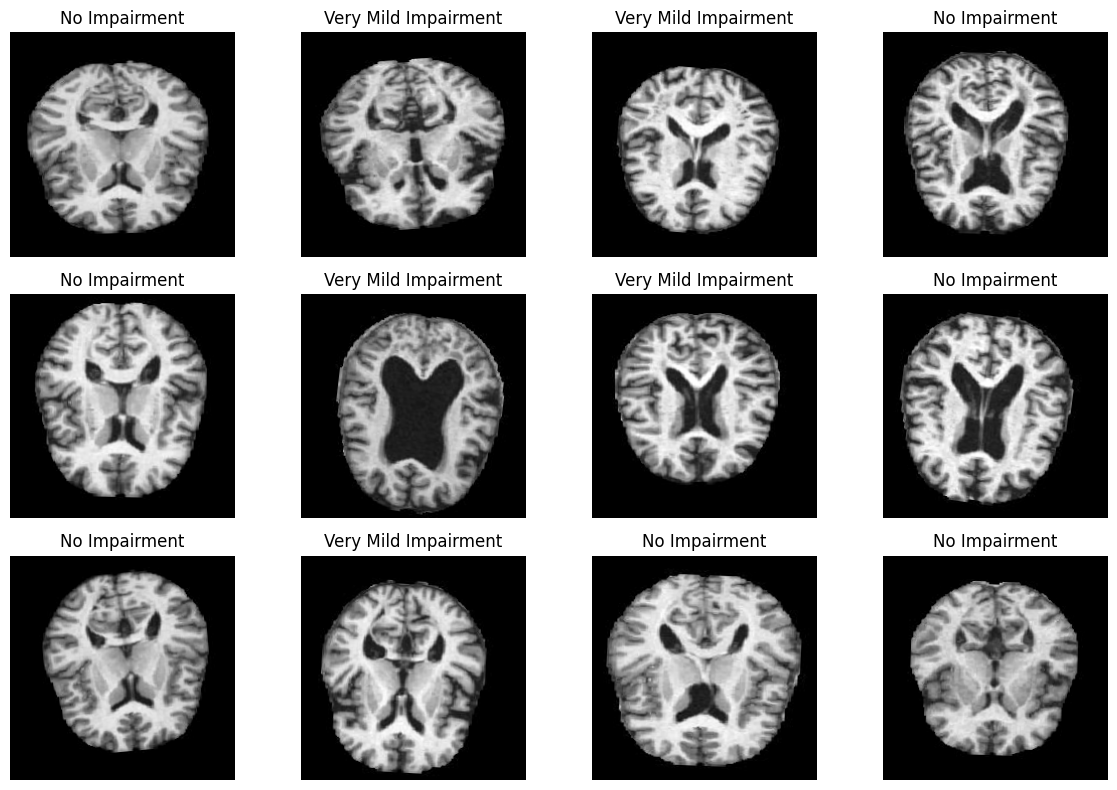

In [6]:
images, labels = next(train_gen)
plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    ax = plt.subplot(3, 4, i+1)
    ax.imshow(np.clip(images[i], 0, 1))
    ax.set_title(CLASS_NAMES[int(np.argmax(labels[i]))])
    ax.axis("off")
plt.tight_layout(); plt.show(); train_gen.reset()

## 7. ViT hyperparameters

The model is trained from scratch rather than using ImageNet-pretrained weights. A 224×224 MRI is divided into 16×16 patches, producing 196 image tokens. Four transformer encoder blocks learn global relationships among those patches.

In [7]:
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 4
TRANSFORMER_UNITS = [PROJECTION_DIM * 2, PROJECTION_DIM]
MLP_HEAD_UNITS = [128, 64]
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 40
print("Patches per image:", NUM_PATCHES)

Patches per image: 196


## 8. Patch extraction, positional encoding, and MLP helper

`Patches` converts each image into a sequence of flattened non-overlapping patches. `PatchEncoder` projects every patch to the transformer embedding dimension and adds a learned positional embedding so the model retains spatial order.

In [8]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = L.Dense(units, activation=tf.nn.gelu)(x)
        x = L.Dropout(dropout_rate)(x)
    return x


class Patches(L.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEncoder(L.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = L.Dense(projection_dim)
        self.position_embedding = L.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim,
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config

## 9. Visualize the patch grid

This cell verifies that the MRI is divided into the intended 14×14 grid of 16×16 patches before transformer encoding.

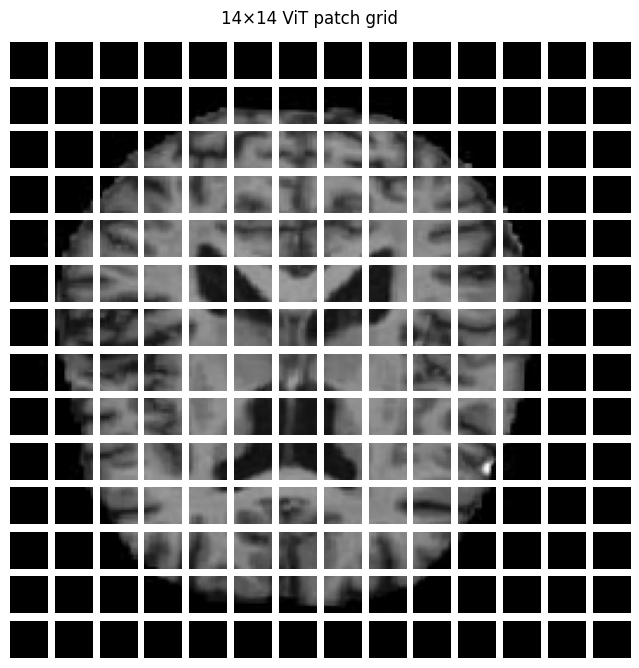

In [9]:
sample_images, _ = next(train_gen)
sample_image = sample_images[0]
patch_tensor = Patches(PATCH_SIZE)(tf.expand_dims(sample_image, axis=0))
grid_size = IMAGE_SIZE // PATCH_SIZE
plt.figure(figsize=(8,8))
for i, patch in enumerate(patch_tensor[0]):
    ax = plt.subplot(grid_size, grid_size, i+1)
    ax.imshow(tf.reshape(patch, (PATCH_SIZE, PATCH_SIZE, 3)))
    ax.axis('off')
plt.suptitle(f"{grid_size}×{grid_size} ViT patch grid", y=0.92)
plt.show(); train_gen.reset()

## 10. Build the four-class Vision Transformer

Each encoder block applies layer normalization, multi-head self-attention, residual connections, and a feed-forward MLP. Global average pooling summarizes the patch sequence. The final **four-unit softmax layer** returns one probability for each Alzheimer disease stage.

In [10]:
def build_vit_classifier():
    inputs = L.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="mri_image")
    patches = Patches(PATCH_SIZE, name="patches")(inputs)
    encoded = PatchEncoder(NUM_PATCHES, PROJECTION_DIM, name="patch_encoder")(patches)

    for block_idx in range(TRANSFORMER_LAYERS):
        x1 = L.LayerNormalization(epsilon=1e-6, name=f"block_{block_idx+1}_ln1")(encoded)
        attention = L.MultiHeadAttention(
            num_heads=NUM_HEADS, key_dim=PROJECTION_DIM // NUM_HEADS,
            dropout=0.1, name=f"block_{block_idx+1}_attention"
        )(x1, x1)
        x2 = L.Add(name=f"block_{block_idx+1}_skip1")([encoded, attention])
        x3 = L.LayerNormalization(epsilon=1e-6, name=f"block_{block_idx+1}_ln2")(x2)
        x3 = mlp(x3, TRANSFORMER_UNITS, 0.1)
        encoded = L.Add(name=f"block_{block_idx+1}_skip2")([x2, x3])

    representation = L.LayerNormalization(epsilon=1e-6, name="final_layer_norm")(encoded)
    representation = L.GlobalAveragePooling1D(name="global_average_pooling")(representation)
    representation = L.Dropout(0.30)(representation)
    features = mlp(representation, MLP_HEAD_UNITS, 0.30)
    outputs = L.Dense(N_CLASSES, activation="softmax", name="disease_stage_probabilities")(features)
    return tf.keras.Model(inputs, outputs, name="ViT_Alzheimer_MRI_From_Scratch")

model = build_vit_classifier()
model.summary()

Model: "ViT_Alzheimer_MRI_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_image           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ mri_image[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ln1         │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attention   │ (None, 196, 64)   │     16,640 │ block_1_ln1[0][0… │
│ (MultiHeadAttentio… │                   │            │ block_1_ln1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_skip1 (Add) │ (None, 196, 64)   │          0 │ patch_encoder[0]… │
│                     │                   │            │ block_1_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ln2         │ (None, 196, 64)   │        128 │ block_1_skip1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ block_1_ln2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_skip2 (Add) │ (None, 196, 64)   │          0 │ block_1_skip1[0]… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ln1         │ (None, 196, 64)   │        128 │ block_1_skip2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attention   │ (None, 196, 64)   │     16,640 │ block_2_ln1[0][0… │
│ (MultiHeadAttentio… │                   │            │ block_2_ln1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_skip1 (Add) │ (None, 196, 64)   │          0 │ block_1_skip2[0]… │
│                     │                   │            │ block_2_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ln2         │ (None, 196, 64)   │        128 │ block_2_skip1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ block_2_ln2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 196, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 212,612 (830.52 KB)

 Trainable params: 212,612 (830.52 KB)

 Non-trainable params: 0 (0.00 B)

## 11. AdamW optimization and multiclass objective

AdamW combines adaptive optimization with decoupled weight decay. A cosine learning-rate schedule gradually reduces the learning rate. Categorical cross-entropy with mild label smoothing is used for the four mutually exclusive classes; categorical accuracy and top-2 accuracy are tracked during training.

In [ ]:
steps_per_epoch = int(np.ceil(train_gen.n / train_gen.batch_size))
decay_steps = steps_per_epoch * EPOCHS
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(LEARNING_RATE, decay_steps, alpha=0.05)
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, clipnorm=1.0)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
             tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")]
)

## 12. Train with validation-based checkpointing

Early stopping and model checkpointing monitor validation accuracy. The official test set is not consulted during training or model selection. Training history is also written to CSV for later reporting and reproducibility.

In [ ]:
best_model_path = OUTPUT_DIR / "best_vit_alzheimer_mri_4class.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=7, min_delta=1e-4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(str(best_model_path), monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    tf.keras.callbacks.CSVLogger(str(OUTPUT_DIR / "training_history.csv")),
    tf.keras.callbacks.TerminateOnNaN(),
]
history = model.fit(train_gen, validation_data=valid_gen, epochs=EPOCHS,
                    class_weight=class_weight, callbacks=callbacks, verbose=1)

## 13. Training and validation curves

Learning curves help identify underfitting, overfitting, and convergence behavior. The plots are saved as high-resolution PNG files suitable for later inspection or manuscript figure preparation.

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / "history_dataframe.csv", index=False)
for metric in ["loss", "accuracy", "top2_accuracy"]:
    if metric not in history.history: continue
    plt.figure(figsize=(7,5))
    plt.plot(history.history[metric], label=f"Train {metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"Validation {metric}")
    plt.xlabel("Epoch"); plt.ylabel(metric.replace('_',' ').title())
    plt.title(f"Training vs Validation {metric.replace('_',' ').title()}")
    plt.legend(); plt.grid(alpha=0.25); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"curve_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 14. Final held-out test evaluation

Only after model selection is complete is the official test set evaluated. Softmax probabilities are retained for multiclass ROC analysis and for exporting case-level predictions.

In [ ]:
test_gen.reset()
test_results = model.evaluate(test_gen, verbose=1, return_dict=True)
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1)
y_true = test_gen.classes.astype(int)
y_pred = np.argmax(y_prob, axis=1)
print("FINAL KERAS TEST METRICS")
for name, value in test_results.items(): print(f"{name:20s}: {value:.4f}")

## 15. Research metrics: Balanced Accuracy, MCC, macro scores, and confusion matrix

Balanced Accuracy gives equal importance to each class recall, while MCC summarizes agreement between predicted and true multiclass labels and remains informative under imbalance. Macro precision, recall, and F1 weight each Alzheimer stage equally. The classification report provides per-class precision, recall, F1, and support.

In [ ]:
acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)
y_true_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))
macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
weighted_auc = roc_auc_score(y_true_bin, y_prob, average="weighted", multi_class="ovr")

print(f"Accuracy              : {acc:.4f}")
print(f"Balanced Accuracy     : {bal_acc:.4f}")
print(f"Matthews CC (MCC)     : {mcc:.4f}")
print(f"Macro Precision       : {macro_precision:.4f}")
print(f"Macro Recall          : {macro_recall:.4f}")
print(f"Macro F1              : {macro_f1:.4f}")
print(f"Macro ROC-AUC (OvR)   : {macro_auc:.4f}")
print(f"Weighted ROC-AUC (OvR): {weighted_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))
plt.figure(figsize=(8,7)); plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks(np.arange(N_CLASSES), CLASS_NAMES, rotation=35, ha="right")
plt.yticks(np.arange(N_CLASSES), CLASS_NAMES)
plt.xlabel("Predicted class"); plt.ylabel("True class"); plt.title("ViT Test Confusion Matrix")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight"); plt.show()

## 16. One-vs-rest ROC curves for all four Alzheimer stages

For multiclass ROC analysis, each disease stage is treated as the positive class in turn and compared with the other three stages. The macro-average AUC summarizes discrimination across all four classes without allowing a larger class to dominate.

In [ ]:
plt.figure(figsize=(8,7))
per_class_auc = {}
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
    per_class_auc[class_name] = auc_i
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc_i:.4f})")
plt.plot([0,1],[0,1],"--",label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"One-vs-Rest ROC Curves (Macro AUC={macro_auc:.4f})")
plt.legend(fontsize=9); plt.grid(alpha=0.25); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "multiclass_roc_curves.png", dpi=300, bbox_inches="tight"); plt.show()

## 17. Save predictions, metrics, class-level results, and experiment configuration

This section exports the numerical outputs needed for an academic article: case-level predictions and probabilities, overall metrics, per-class classification statistics, AUC values, and the main experiment configuration. Keeping these files together supports reproducibility and later statistical comparison with alternative models.

In [ ]:
predictions_df = df_test.copy()
predictions_df["true_label"] = y_true
predictions_df["predicted_label"] = y_pred
predictions_df["predicted_class"] = [CLASS_NAMES[i] for i in y_pred]
for i, class_name in enumerate(CLASS_NAMES):
    predictions_df[f"prob_{normalize_name(class_name)}"] = y_prob[:, i]
predictions_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.to_csv(OUTPUT_DIR / "classification_report.csv")
pd.DataFrame({"class_name": list(per_class_auc.keys()), "roc_auc_ovr": list(per_class_auc.values())}).to_csv(OUTPUT_DIR / "per_class_auc.csv", index=False)

metrics = {
    **{f"keras_{k}": float(v) for k,v in test_results.items()},
    "accuracy_sklearn": float(acc), "balanced_accuracy": float(bal_acc), "mcc": float(mcc),
    "macro_precision": float(macro_precision), "macro_recall": float(macro_recall), "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_precision), "weighted_recall": float(weighted_recall), "weighted_f1": float(weighted_f1),
    "macro_roc_auc_ovr": float(macro_auc), "weighted_roc_auc_ovr": float(weighted_auc),
}
pd.DataFrame([metrics]).to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)

config = {
    "seed": SEED, "image_size": IMAGE_SIZE, "batch_size": BATCH_SIZE,
    "validation_fraction_from_training": VALIDATION_FRACTION,
    "classes": CLASS_NAMES, "patch_size": PATCH_SIZE, "num_patches": NUM_PATCHES,
    "projection_dim": PROJECTION_DIM, "num_heads": NUM_HEADS,
    "transformer_layers": TRANSFORMER_LAYERS, "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY, "max_epochs": EPOCHS,
    "best_model": str(best_model_path),
}
with open(OUTPUT_DIR / "experiment_config.json", "w") as f: json.dump(config, f, indent=2)
print("All research outputs saved to:", OUTPUT_DIR)

## 18. Manuscript-oriented interpretation guide

When reporting this experiment, distinguish the **training/validation procedure** from the final held-out test evaluation. Report the number of images per split and class, the augmentation policy, ViT architecture/hyperparameters, optimizer and stopping criterion, and all final test metrics. Because the supplied dataset contains real and WGAN-GP-generated training images, the article should also state that synthetic augmentation/balancing is a property of the dataset itself, while the geometric/intensity augmentation in this notebook is an additional training-time transformation.

For comparisons with other architectures, use the same train/validation/test protocol and random seed where applicable. Do not select hyperparameters using the official test set. Balanced Accuracy, MCC, macro F1, per-class recall, and the confusion matrix are particularly useful for showing whether gains extend beyond the majority or easiest disease stages.